# Pneumonia Detection CNN Model

This notebook trains a CNN to classify chest X-rays into `NORMAL` vs `PNEUMONIA`.

In [1]:
import os
import sys
import json
import random
import pathlib
import importlib.util
import subprocess
from datetime import datetime

# Local environments can miss optional tuning deps required by keras-tuner.
for pkg_name in ["tensorboard", "keras-tuner"]:
    if importlib.util.find_spec(pkg_name.replace("-", "_")) is None:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", pkg_name], check=False)

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
import keras
import keras_tuner as kt
from keras import layers
from tensorflow.keras.models import load_model

from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.model_selection import train_test_split

keras.utils.set_random_seed(42)
np.random.seed(42)
random.seed(42)

print("TensorFlow:", tf.__version__)
print("Keras:", keras.__version__)

TensorFlow: 2.21.0
Keras: 3.13.2


In [2]:
USE_COLAB = False  # Set to False to run locally

In [3]:
# Configuration
if USE_COLAB:
    from google.colab import drive

    drive.mount('/content/drive')
    DATASET_ROOT = "/content/drive/MyDrive/x-ray-dataset/"
    SAVE_DIR = pathlib.Path("/content/drive/MyDrive/saved_models")
else:
    DATASET_ROOT = "dataset"
    SAVE_DIR = pathlib.Path("saved_models")

TRAIN_DIR = os.path.join(DATASET_ROOT, "train")
VAL_DIR = os.path.join(DATASET_ROOT, "val")  # merged into training pool if present
TEST_DIR = os.path.join(DATASET_ROOT, "test")

IMG_SIZE = (150, 150)
BATCH_SIZE = 32
EPOCHS = 20
VAL_SPLIT = 0.1
AUTOTUNE = tf.data.AUTOTUNE

SAVE_DIR.mkdir(parents=True, exist_ok=True)

BASELINE_CHECKPOINT_PATH = SAVE_DIR / "baseline_best_checkpoint.keras"
TUNED_CHECKPOINT_PATH = SAVE_DIR / "baseline_tuned_best_checkpoint.keras"
MODEL_PATH = BASELINE_CHECKPOINT_PATH  # kept for backward compatibility in earlier cells

for split_path in [TRAIN_DIR, TEST_DIR]:
    if not os.path.isdir(split_path):
        raise FileNotFoundError(f"Missing directory: {split_path}")

print(f"Environment: {'Google Colab' if USE_COLAB else 'Local'}")
print(f"Dataset root: {DATASET_ROOT}")
print(f"Model artifacts will be stored in: {SAVE_DIR}")

Environment: Local
Dataset root: dataset
Model artifacts will be stored in: saved_models


In [4]:
# Notebook context
print(f"Runtime mode selected via USE_COLAB={USE_COLAB}.")

Runtime mode selected via USE_COLAB=False.


## 1) Exploratory Data Analysis

Quickly inspect class counts, class balance per split, and a few raw samples before building the training pipeline.

In [5]:
def count_images(split_dir):
    counts = {}
    for class_name in ["NORMAL", "PNEUMONIA"]:
        class_dir = os.path.join(split_dir, class_name)
        if not os.path.isdir(class_dir):
            counts[class_name] = 0
            continue
        counts[class_name] = len([
            f for f in os.listdir(class_dir)
            if os.path.isfile(os.path.join(class_dir, f))
        ])
    return counts

split_counts = {
    "train": count_images(TRAIN_DIR),
    "test": count_images(TEST_DIR),
}
if os.path.isdir(VAL_DIR):
    split_counts["val"] = count_images(VAL_DIR)

for split_name, c in split_counts.items():
    print(f"{split_name.upper()}: NORMAL={c['NORMAL']}, PNEUMONIA={c['PNEUMONIA']}, TOTAL={c['NORMAL'] + c['PNEUMONIA']}")

print("Note: original dataset/val images are merged into the training pool for stratified split.")

TRAIN: NORMAL=1341, PNEUMONIA=3875, TOTAL=5216
TEST: NORMAL=234, PNEUMONIA=390, TOTAL=624
VAL: NORMAL=8, PNEUMONIA=8, TOTAL=16
Note: original dataset/val images are merged into the training pool for stratified split.


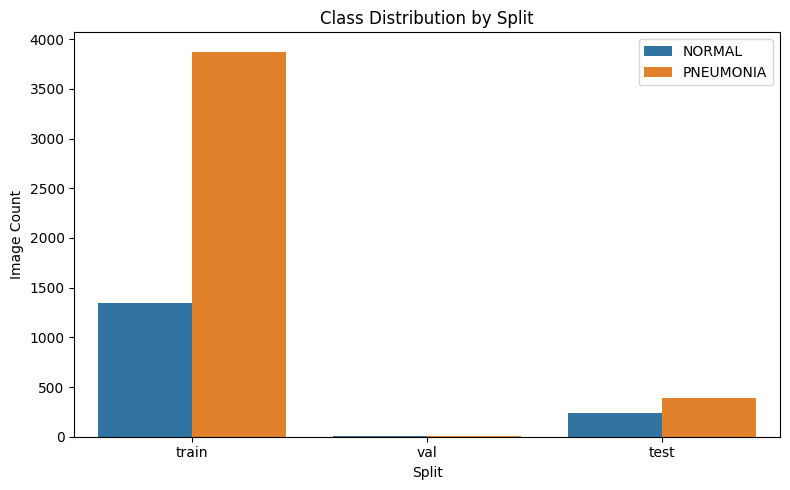

In [6]:
# Class distribution plot
splits = []
classes = []
counts = []

for split_name in ["train", "val", "test"]:
    for class_name in ["NORMAL", "PNEUMONIA"]:
        splits.append(split_name)
        classes.append(class_name)
        counts.append(split_counts[split_name][class_name])

plt.figure(figsize=(8, 5))
sns.barplot(x=splits, y=counts, hue=classes)
plt.title("Class Distribution by Split")
plt.xlabel("Split")
plt.ylabel("Image Count")
plt.tight_layout()
plt.show()

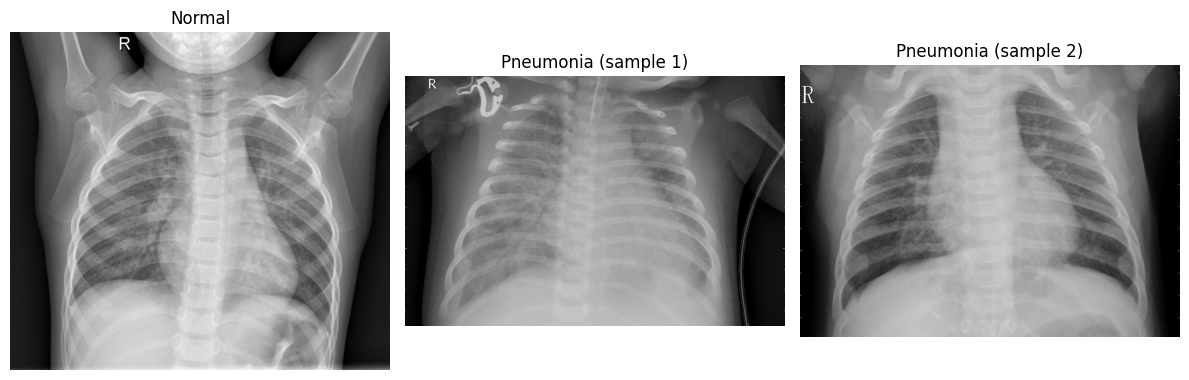

In [7]:
# Visualize sample images from each class in train split
train_normal_dir = os.path.join(TRAIN_DIR, "NORMAL")
train_pneumonia_dir = os.path.join(TRAIN_DIR, "PNEUMONIA")

normal_samples = sorted(os.listdir(train_normal_dir))[:3]
pneumonia_samples = sorted(os.listdir(train_pneumonia_dir))[:3]

sample_paths = [
    os.path.join(train_normal_dir, normal_samples[0]),
    os.path.join(train_pneumonia_dir, pneumonia_samples[0]),
    os.path.join(train_pneumonia_dir, pneumonia_samples[1]),
]

titles = ["Normal", "Pneumonia (sample 1)", "Pneumonia (sample 2)"]

plt.figure(figsize=(12, 4))
for i, (path, title) in enumerate(zip(sample_paths, titles), start=1):
    img = keras.utils.load_img(path, color_mode="grayscale")
    arr = keras.utils.img_to_array(img)
    plt.subplot(1, 3, i)
    plt.imshow(arr.squeeze(), cmap="gray")
    plt.title(title)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [8]:
# Check a few raw image shapes
shape_samples = []
for class_name, class_dir in [("NORMAL", train_normal_dir), ("PNEUMONIA", train_pneumonia_dir)]:
    sample_file = sorted(os.listdir(class_dir))[0]
    sample_path = os.path.join(class_dir, sample_file)
    img = keras.utils.load_img(sample_path)
    shape_samples.append((class_name, sample_file, img.size))  # PIL size = (width, height)

for class_name, file_name, size in shape_samples:
    print(f"{class_name}: {file_name} -> original size (W,H) = {size}")
print(f"Target resize: {IMG_SIZE}")

NORMAL: IM-0115-0001.jpeg -> original size (W,H) = (2090, 1858)
PNEUMONIA: person1000_bacteria_2931.jpeg -> original size (W,H) = (1152, 760)
Target resize: (150, 150)


## 2) Data Loading and Preprocessing

Create stratified train/validation splits and build `tf.data` pipelines with balanced on-the-fly sampling.

In [9]:
# Collect all file paths and labels from train plus optional original val directory
train_root = pathlib.Path(TRAIN_DIR)
val_root = pathlib.Path(VAL_DIR)
all_paths, all_labels = [], []

for source_dir in [train_root, val_root]:
    if not source_dir.is_dir():
        continue
    for class_idx, class_name in enumerate(["NORMAL", "PNEUMONIA"]):
        class_dir = source_dir / class_name
        if not class_dir.is_dir():
            continue
        for img_path in sorted(class_dir.iterdir()):
            if img_path.is_file():
                all_paths.append(str(img_path))
                all_labels.append(class_idx)

all_paths = np.array(all_paths)
all_labels = np.array(all_labels)

# Stratified split so both classes are represented in train and val
train_paths, val_paths, train_labels_raw, val_labels_arr = train_test_split(
    all_paths,
    all_labels,
    test_size=VAL_SPLIT,
    stratify=all_labels,
    random_state=42,
)

normal_mask = train_labels_raw == 0
pneumonia_mask = train_labels_raw == 1
normal_count = int(normal_mask.sum())
pneumonia_count = int(pneumonia_mask.sum())

if normal_count == 0 or pneumonia_count == 0:
    raise ValueError("Both NORMAL and PNEUMONIA classes must exist in the train split.")

print(f"Source pool size (train + optional original val): {len(all_paths)} images")
print(f"Stratified split (before balancing): {len(train_paths)} train, {len(val_paths)} val")
print(f"  Train before -> NORMAL={normal_count}, PNEUMONIA={pneumonia_count}")
print(f"  Val          -> NORMAL={int((val_labels_arr==0).sum())}, PNEUMONIA={int((val_labels_arr==1).sum())}")

def _load_image(path, label):
    raw = tf.io.read_file(path)
    img = tf.image.decode_jpeg(raw, channels=3)
    img = tf.image.resize(img, IMG_SIZE)
    return img, tf.expand_dims(tf.cast(label, tf.float32), axis=0)

Source pool size (train + optional original val): 5232 images
Stratified split (before balancing): 4708 train, 524 val
  Train before -> NORMAL=1214, PNEUMONIA=3494
  Val          -> NORMAL=135, PNEUMONIA=389


In [10]:
# Build class-specific datasets for balanced on-the-fly sampling
normal_ds = (
    tf.data.Dataset.from_tensor_slices((train_paths[normal_mask], train_labels_raw[normal_mask].astype("float32")))
    .shuffle(normal_count, seed=42, reshuffle_each_iteration=True)
    .repeat()
    .map(_load_image, num_parallel_calls=AUTOTUNE)
)

pneumonia_ds = (
    tf.data.Dataset.from_tensor_slices((train_paths[pneumonia_mask], train_labels_raw[pneumonia_mask].astype("float32")))
    .shuffle(pneumonia_count, seed=42, reshuffle_each_iteration=True)
    .repeat()
    .map(_load_image, num_parallel_calls=AUTOTUNE)
)

train_ds = tf.data.Dataset.sample_from_datasets(
    [normal_ds, pneumonia_ds],
    weights=[0.5, 0.5],
    seed=42,
).batch(BATCH_SIZE)

# Infinite balanced dataset -> define epoch boundary explicitly.
steps_per_epoch = max(1, (2 * pneumonia_count) // BATCH_SIZE)
print(f"  Balanced sampling -> NORMAL:PNEUMONIA = 1:1 per epoch")
print(f"  Steps per epoch: {steps_per_epoch}")

val_ds = (
    tf.data.Dataset.from_tensor_slices((val_paths, val_labels_arr.astype("float32")))
    .map(_load_image, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
)

test_ds = keras.utils.image_dataset_from_directory(
    TEST_DIR,
    labels="inferred",
    label_mode="binary",
    class_names=["NORMAL", "PNEUMONIA"],
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False,
)

class_names = ["NORMAL", "PNEUMONIA"]
print("Class names:", class_names)
print("Note: dataset/val folder excluded; validation split is stratified from dataset/train.")

  Balanced sampling -> NORMAL:PNEUMONIA = 1:1 per epoch
  Steps per epoch: 218
Found 624 files belonging to 2 classes.
Class names: ['NORMAL', 'PNEUMONIA']
Note: dataset/val folder excluded; validation split is stratified from dataset/train.


In [11]:
# Medically safer data augmentation layers (active only during training)
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.10),
    layers.RandomTranslation(0.05, 0.05),
    layers.RandomContrast(0.10),
], name="data_augmentation")

In [12]:
# Performance optimization for tf.data pipelines
# train_ds is infinite (repeat + sample_from_datasets), so we only prefetch.
train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.cache().prefetch(AUTOTUNE)
test_ds = test_ds.cache().prefetch(AUTOTUNE)

print("Datasets are ready.")

Datasets are ready.


## 2.1) Oversampling and Augmentation Checks

Validate that the balanced sampling strategy and augmentation pipeline are behaving as expected.

Class distribution check
  Train before balancing: NORMAL=1214, PNEUMONIA=3494
  Train after balancing : NORMAL~3488, PNEUMONIA~3488 (sampled)
  Validation            : NORMAL=135, PNEUMONIA=389


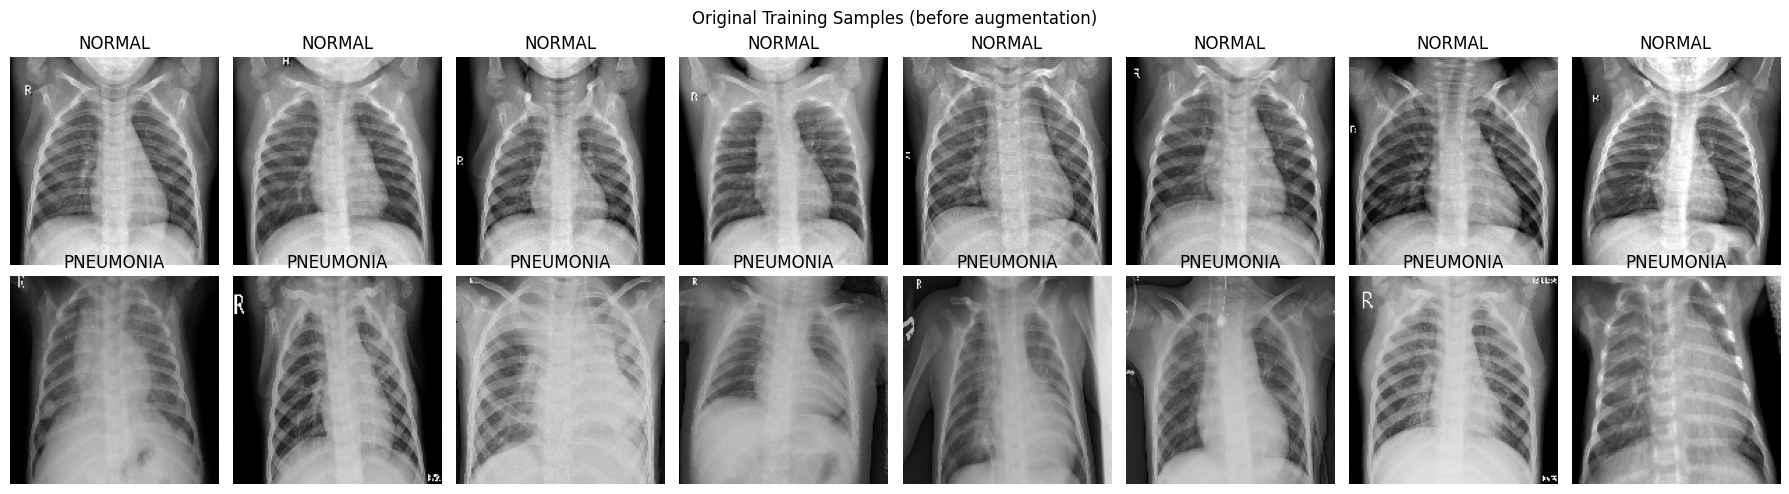

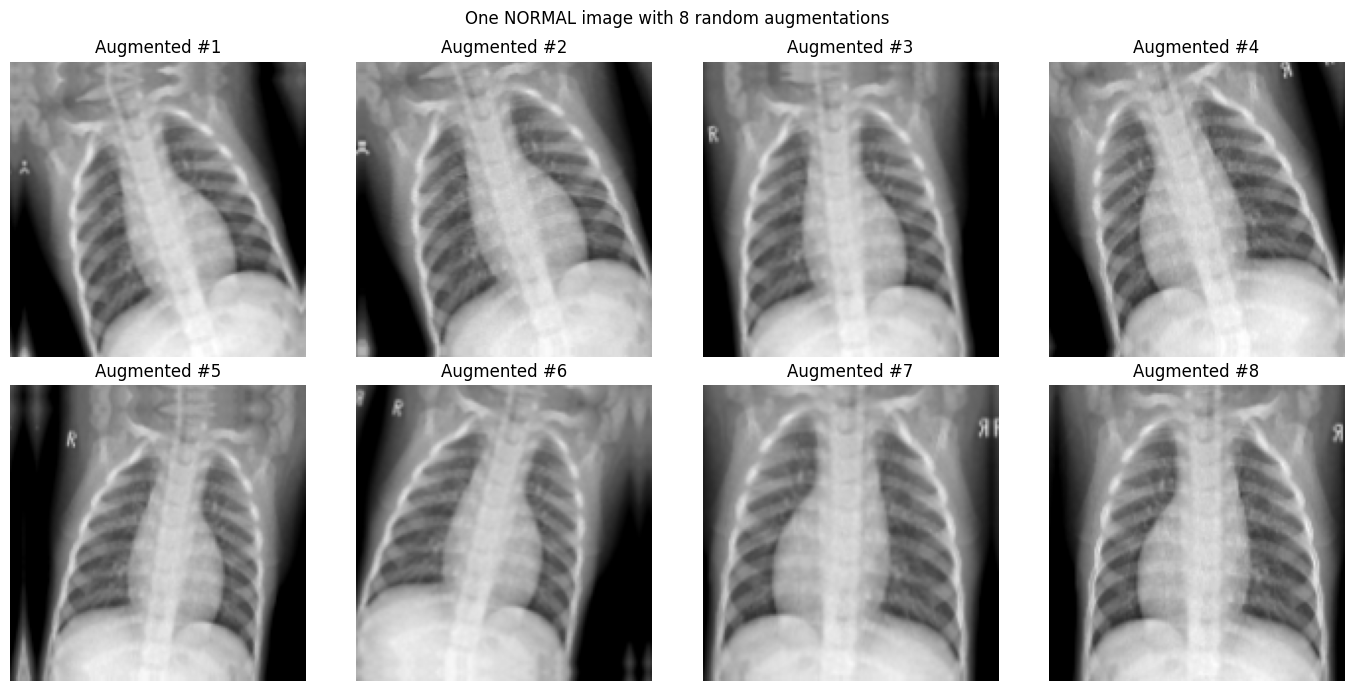

In [13]:
normal_paths = train_paths[train_labels_raw == 0]
pneumonia_paths = train_paths[train_labels_raw == 1]

# For diagnostics only: effective per-epoch class counts under 1:1 sampled training.
balanced_epoch_count = steps_per_epoch * BATCH_SIZE // 2

print("Class distribution check")
print(f"  Train before balancing: NORMAL={(train_labels_raw==0).sum()}, PNEUMONIA={(train_labels_raw==1).sum()}")
print(f"  Train after balancing : NORMAL~{balanced_epoch_count}, PNEUMONIA~{balanced_epoch_count} (sampled)")
print(f"  Validation            : NORMAL={(val_labels_arr==0).sum()}, PNEUMONIA={(val_labels_arr==1).sum()}")

rng = np.random.default_rng(42)
fig, axes = plt.subplots(2, 8, figsize=(18, 5))
normal_sample_paths = rng.choice(normal_paths, size=min(8, len(normal_paths)), replace=False)
pneumonia_sample_paths = rng.choice(pneumonia_paths, size=min(8, len(pneumonia_paths)), replace=False)

for i in range(8):
    if i < len(normal_sample_paths):
        img = keras.utils.load_img(normal_sample_paths[i], target_size=IMG_SIZE)
        axes[0, i].imshow(img)
        axes[0, i].set_title("NORMAL")
    axes[0, i].axis("off")

    if i < len(pneumonia_sample_paths):
        img = keras.utils.load_img(pneumonia_sample_paths[i], target_size=IMG_SIZE)
        axes[1, i].imshow(img)
        axes[1, i].set_title("PNEUMONIA")
    axes[1, i].axis("off")

plt.suptitle("Original Training Samples (before augmentation)")
plt.tight_layout()
plt.show()

sample_normal = keras.utils.load_img(normal_paths[0], target_size=IMG_SIZE)
sample_tensor = tf.expand_dims(tf.cast(keras.utils.img_to_array(sample_normal), tf.float32), axis=0)

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for idx, ax in enumerate(axes.flat):
    aug_img = data_augmentation(sample_tensor, training=True)[0]
    aug_img = tf.clip_by_value(aug_img / 255.0, 0.0, 1.0)
    ax.imshow(aug_img)
    ax.set_title(f"Augmented #{idx+1}")
    ax.axis("off")

plt.suptitle("One NORMAL image with 8 random augmentations")
plt.tight_layout()
plt.show()

## 3) Helper Utilities

Define reusable serialization and metadata-saving helpers before training and evaluation.

In [14]:
def _to_serializable(value):
    if isinstance(value, (np.floating, np.integer)):
        return value.item()
    if isinstance(value, np.ndarray):
        return value.tolist()
    return value


def save_model_with_meta(model, name, metrics_dict, history, hyperparams, threshold):
    model_path = SAVE_DIR / f"{name}.keras"
    meta_path = SAVE_DIR / f"{name}_meta.json"

    model.save(model_path)
    history_dict = history.history if hasattr(history, "history") else {}

    metadata = {
        "model_name": name,
        "saved_at": datetime.utcnow().isoformat() + "Z",
        "model_path": str(model_path),
        "threshold": float(threshold),
        "metrics": {k: _to_serializable(v) for k, v in metrics_dict.items()},
        "hyperparameters": {k: _to_serializable(v) for k, v in hyperparams.items()},
        "history": {k: [_to_serializable(x) for x in vals] for k, vals in history_dict.items()},
        "model_params": {
            "total": int(model.count_params()),
            "trainable": int(np.sum([np.prod(v.shape) for v in model.trainable_weights])),
            "non_trainable": int(np.sum([np.prod(v.shape) for v in model.non_trainable_weights])),
        },
    }

    with open(meta_path, "w", encoding="utf-8") as f:
        json.dump(metadata, f, indent=2)

    print(f"Saved model to: {model_path}")
    print(f"Saved metadata to: {meta_path}")

## 4) CNN Model Architecture

Define a regularized baseline CNN with in-graph augmentation and image rescaling for stable training.

In [15]:
inputs = keras.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3))

# Preprocessing inside model graph
x = data_augmentation(inputs)
x = layers.Rescaling(1.0 / 255)(x)

l2_reg = keras.regularizers.l2(1e-4)

# Block 1
x = layers.Conv2D(32, (3, 3), strides=(1, 1), padding="same", activation="relu")(x)
x = layers.BatchNormalization()(x)
x = layers.Conv2D(32, (3, 3), strides=(1, 1), padding="same", activation="relu")(x)
x = layers.BatchNormalization()(x)
x = layers.MaxPooling2D((2, 2))(x)
x = layers.Dropout(0.25)(x)

# Block 2
x = layers.Conv2D(64, (3, 3), strides=(1, 1), padding="same", activation="relu")(x)
x = layers.BatchNormalization()(x)
x = layers.Conv2D(64, (3, 3), strides=(1, 1), padding="same", activation="relu")(x)
x = layers.BatchNormalization()(x)
x = layers.MaxPooling2D((2, 2))(x)
x = layers.Dropout(0.25)(x)

# Block 3
x = layers.Conv2D(128, (3, 3), strides=(1, 1), padding="same", activation="relu")(x)
x = layers.BatchNormalization()(x)
x = layers.Conv2D(128, (3, 3), strides=(1, 1), padding="same", activation="relu")(x)
x = layers.BatchNormalization()(x)
x = layers.MaxPooling2D((2, 2))(x)
x = layers.Dropout(0.25)(x)

# Block 4
x = layers.Conv2D(256, (3, 3), strides=(1, 1), padding="same", activation="relu")(x)
x = layers.BatchNormalization()(x)
x = layers.Conv2D(256, (3, 3), strides=(1, 1), padding="same", activation="relu")(x)
x = layers.BatchNormalization()(x)
x = layers.MaxPooling2D((2, 2))(x)
x = layers.Dropout(0.25)(x)

# Regularized classifier
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(128, activation="relu", kernel_regularizer=l2_reg)(x)
x = layers.Dropout(0.20)(x)
outputs = layers.Dense(1, activation="sigmoid")(x)

model = keras.Model(inputs=inputs, outputs=outputs, name="pneumonia_cnn_v2")
model.summary()

Model: "pneumonia_cnn_v2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 150, 150, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 150, 150, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 150, 150, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 150, 150, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 75, 75, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 75, 75, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 75, 75, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 75, 75, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 37, 37, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 37, 37, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 37, 37, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 37, 37, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 37, 37, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 37, 37, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 18, 18, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 18, 18, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 18, 18, 256)    │       295,16

 Total params: 1,209,121 (4.61 MB)

 Trainable params: 1,207,201 (4.61 MB)

 Non-trainable params: 1,920 (7.50 KB)

## 5) Compile Model

Compile the baseline model with robust classification metrics and gradient clipping for better optimization stability.

In [16]:
print("Balanced training split distribution (sampled):")
print(f"  NORMAL~{steps_per_epoch * BATCH_SIZE // 2}, PNEUMONIA~{steps_per_epoch * BATCH_SIZE // 2}, TOTAL~{steps_per_epoch * BATCH_SIZE}")
print("Validation split distribution:")
print(f"  NORMAL={int((val_labels_arr==0).sum())}, PNEUMONIA={int((val_labels_arr==1).sum())}, TOTAL={len(val_labels_arr)}")

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001, clipnorm=1.0),
    loss=keras.losses.BinaryCrossentropy(label_smoothing=0.02),
    metrics=[
        "accuracy",
        keras.metrics.AUC(name="auc"),
        keras.metrics.AUC(name="pr_auc", curve="PR")
    ],
)

print("Model compiled with PR-AUC monitoring and smoother optimization settings.")

Balanced training split distribution (sampled):
  NORMAL~3488, PNEUMONIA~3488, TOTAL~6976
Validation split distribution:
  NORMAL=135, PNEUMONIA=389, TOTAL=524
Model compiled with PR-AUC monitoring and smoother optimization settings.


## 6) Train the CNN

Train with callbacks (early stopping, LR schedule, checkpointing) and resume from checkpoint when available.

In [17]:
my_callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        mode="max",
        patience=3,
        restore_best_weights=True,
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_accuracy",
        mode="max",
        factor=0.3,
        patience=2,
        min_lr=0.000001,
    ),
    keras.callbacks.ModelCheckpoint(
        BASELINE_CHECKPOINT_PATH,
        monitor="val_accuracy",
        mode="max",
        save_best_only=True,
    ),
    keras.callbacks.TerminateOnNaN(),
]

if BASELINE_CHECKPOINT_PATH.exists():
    print(f"Loading existing baseline checkpoint: {BASELINE_CHECKPOINT_PATH}")
    model = load_model(BASELINE_CHECKPOINT_PATH)
    history = None
else:
    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=EPOCHS,
        steps_per_epoch=steps_per_epoch,
        callbacks=my_callbacks,
    )
    print(f"Best baseline checkpoint saved to: {BASELINE_CHECKPOINT_PATH}")

Loading existing baseline checkpoint: saved_models\baseline_best_checkpoint.keras


## 7) Evaluate and Visualize Results

Load the best checkpoint, tune decision threshold on validation data, and report test-set performance.

In [18]:
# Plot training curves (loss, accuracy, and AUC)
if history is None:
    print("Training history is unavailable because model was loaded from checkpoint.")
else:
    plt.figure(figsize=(15, 4))

    plt.subplot(1, 3, 1)
    plt.plot(history.history["accuracy"], label="Train Accuracy")
    plt.plot(history.history["val_accuracy"], label="Val Accuracy")
    plt.title("Accuracy Over Epochs")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()

    plt.subplot(1, 3, 2)
    plt.plot(history.history["loss"], label="Train Loss")
    plt.plot(history.history["val_loss"], label="Val Loss")
    plt.title("Loss Over Epochs")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()

    plt.subplot(1, 3, 3)
    plt.plot(history.history["auc"], label="Train AUC")
    plt.plot(history.history["val_auc"], label="Val AUC")
    plt.title("AUC Over Epochs")
    plt.xlabel("Epoch")
    plt.ylabel("AUC")
    plt.legend()

    plt.tight_layout()
    plt.show()

Training history is unavailable because model was loaded from checkpoint.


In [19]:
# Baseline checkpoint loading stage
print("Loading baseline checkpoint for threshold tuning and test evaluation...")

Loading baseline checkpoint for threshold tuning and test evaluation...


In [20]:
MODEL_TO_LOAD = BASELINE_CHECKPOINT_PATH
if not MODEL_TO_LOAD.exists():
    raise FileNotFoundError(
        f"Model file not found at {MODEL_TO_LOAD}. Run training first."
    )

best_model = load_model(MODEL_TO_LOAD)
print(f"Loaded model from: {MODEL_TO_LOAD}")
print(f"Model input shape: {best_model.input_shape}")
print(f"Model output shape: {best_model.output_shape}")

Loaded model from: saved_models\baseline_best_checkpoint.keras
Model input shape: (None, 150, 150, 3)
Model output shape: (None, 1)


In [21]:
# Threshold selection stage
print("Searching the best decision threshold on validation data (macro F1)...")

Searching the best decision threshold on validation data (macro F1)...


In [22]:
# Threshold tuning on validation split
val_true_batches, val_prob_batches = [], []
for images, labels in val_ds:
    probs = best_model.predict(images, verbose=0).ravel()
    val_prob_batches.append(probs)
    val_true_batches.append(labels.numpy().ravel())

val_true = np.concatenate(val_true_batches).astype(int)
val_prob = np.concatenate(val_prob_batches)

thresholds = np.linspace(0.05, 0.95, 91)
val_macro_f1_scores = []
for t in thresholds:
    val_pred_t = (val_prob >= t).astype(int)
    report_t = classification_report(
        val_true,
        val_pred_t,
        target_names=["NORMAL", "PNEUMONIA"],
        output_dict=True,
        zero_division=0,
    )
    macro_f1 = (report_t["NORMAL"]["f1-score"] + report_t["PNEUMONIA"]["f1-score"]) / 2
    val_macro_f1_scores.append(macro_f1)

best_threshold = float(thresholds[int(np.argmax(val_macro_f1_scores))])
print(f"Best threshold from validation split (macro F1): {best_threshold:.2f}")

Best threshold from validation split (macro F1): 0.34


Test ROC-AUC: 0.9512


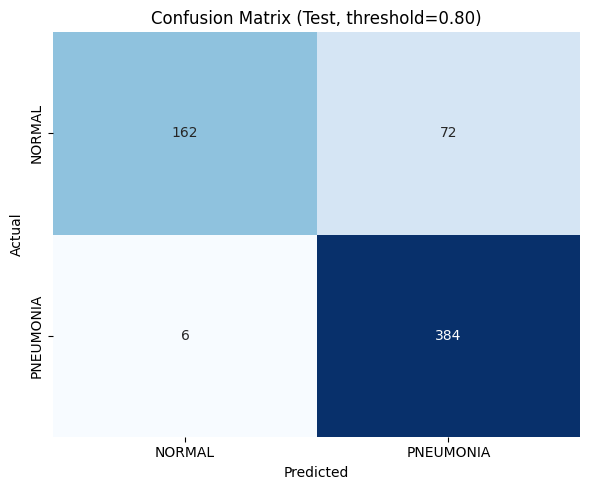

Classification Report (Test):

              precision    recall  f1-score   support

      NORMAL       0.96      0.69      0.81       234
   PNEUMONIA       0.84      0.98      0.91       390

    accuracy                           0.88       624
   macro avg       0.90      0.84      0.86       624
weighted avg       0.89      0.88      0.87       624



In [23]:
# Predictions on test set
best_threshold = 0.8
y_true_batches, y_prob_batches = [], []
for images, labels in test_ds:
    probs = best_model.predict(images, verbose=0).ravel()
    y_prob_batches.append(probs)
    y_true_batches.append(labels.numpy().ravel())

y_true = np.concatenate(y_true_batches).astype(int)
y_prob = np.concatenate(y_prob_batches)
y_pred = (y_prob >= best_threshold).astype(int)

test_roc_auc = float(roc_auc_score(y_true, y_prob))
print(f"Test ROC-AUC: {test_roc_auc:.4f}")

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    xticklabels=["NORMAL", "PNEUMONIA"],
    yticklabels=["NORMAL", "PNEUMONIA"],
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Confusion Matrix (Test, threshold={best_threshold:.2f})")
plt.tight_layout()
plt.show()

print("Classification Report (Test):\n")
print(classification_report(y_true, y_pred, target_names=["NORMAL", "PNEUMONIA"], zero_division=0))

In [24]:
# Persist baseline model artifacts and metadata
report = classification_report(
    y_true,
    y_pred,
    target_names=["NORMAL", "PNEUMONIA"],
    output_dict=True,
    zero_division=0,
)

baseline_metrics = {
    "accuracy": float((y_pred == y_true).mean()),
    "auc": test_roc_auc,
    "precision": float(report["PNEUMONIA"]["precision"]),
    "recall": float(report["PNEUMONIA"]["recall"]),
    "f1": float(report["PNEUMONIA"]["f1-score"]),
}

baseline_hyperparams = {
    "img_size": IMG_SIZE,
    "batch_size": BATCH_SIZE,
    "epochs": EPOCHS,
    "optimizer": "Adam",
    "learning_rate": 1e-4,
    "balanced_sampling": "sample_from_datasets(weights=[0.5, 0.5])",
    "steps_per_epoch": steps_per_epoch,
    "threshold_search_range": [0.05, 0.95, 91],
}

if "history" not in globals():
    history = None

save_model_with_meta(best_model, "baseline_cnn", baseline_metrics, history, baseline_hyperparams, best_threshold)

print("\nSummary:")
print("- Validation now uses a large split from dataset/train instead of the tiny val folder.")
print("- Training uses balanced on-the-fly sampling with repeat + sample_from_datasets.")
print("- Decision threshold tuned on validation split before final test evaluation.")

Saved model to: saved_models\baseline_cnn.keras
Saved metadata to: saved_models\baseline_cnn_meta.json

Summary:
- Validation now uses a large split from dataset/train instead of the tiny val folder.
- Training uses balanced on-the-fly sampling with repeat + sample_from_datasets.
- Decision threshold tuned on validation split before final test evaluation.


NORMAL samples: 234 | PNEUMONIA samples: 390


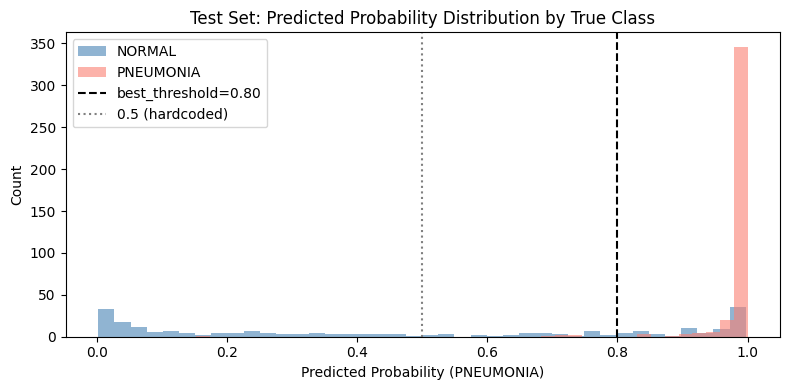

In [25]:
# Diagnostic: probability distribution by true class on test set
from IPython.display import display

# Flatten to 1D arrays to avoid shape/indexing edge cases.
y_true_arr = np.asarray(y_true).reshape(-1)
y_prob_arr = np.asarray(y_prob).reshape(-1)

normal_probs = y_prob_arr[y_true_arr == 0]
pneumonia_probs = y_prob_arr[y_true_arr == 1]

print(f"NORMAL samples: {normal_probs.size} | PNEUMONIA samples: {pneumonia_probs.size}")

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(normal_probs, bins=40, alpha=0.6, label="NORMAL", color="steelblue")
ax.hist(pneumonia_probs, bins=40, alpha=0.6, label="PNEUMONIA", color="salmon")
ax.axvline(best_threshold, color="black", linestyle="--", label=f"best_threshold={best_threshold:.2f}")
ax.axvline(0.5, color="gray", linestyle=":", label="0.5 (hardcoded)")
ax.set_xlabel("Predicted Probability (PNEUMONIA)")
ax.set_ylabel("Count")
ax.set_title("Test Set: Predicted Probability Distribution by True Class")
ax.legend()
fig.tight_layout()

display(fig)
plt.close(fig)

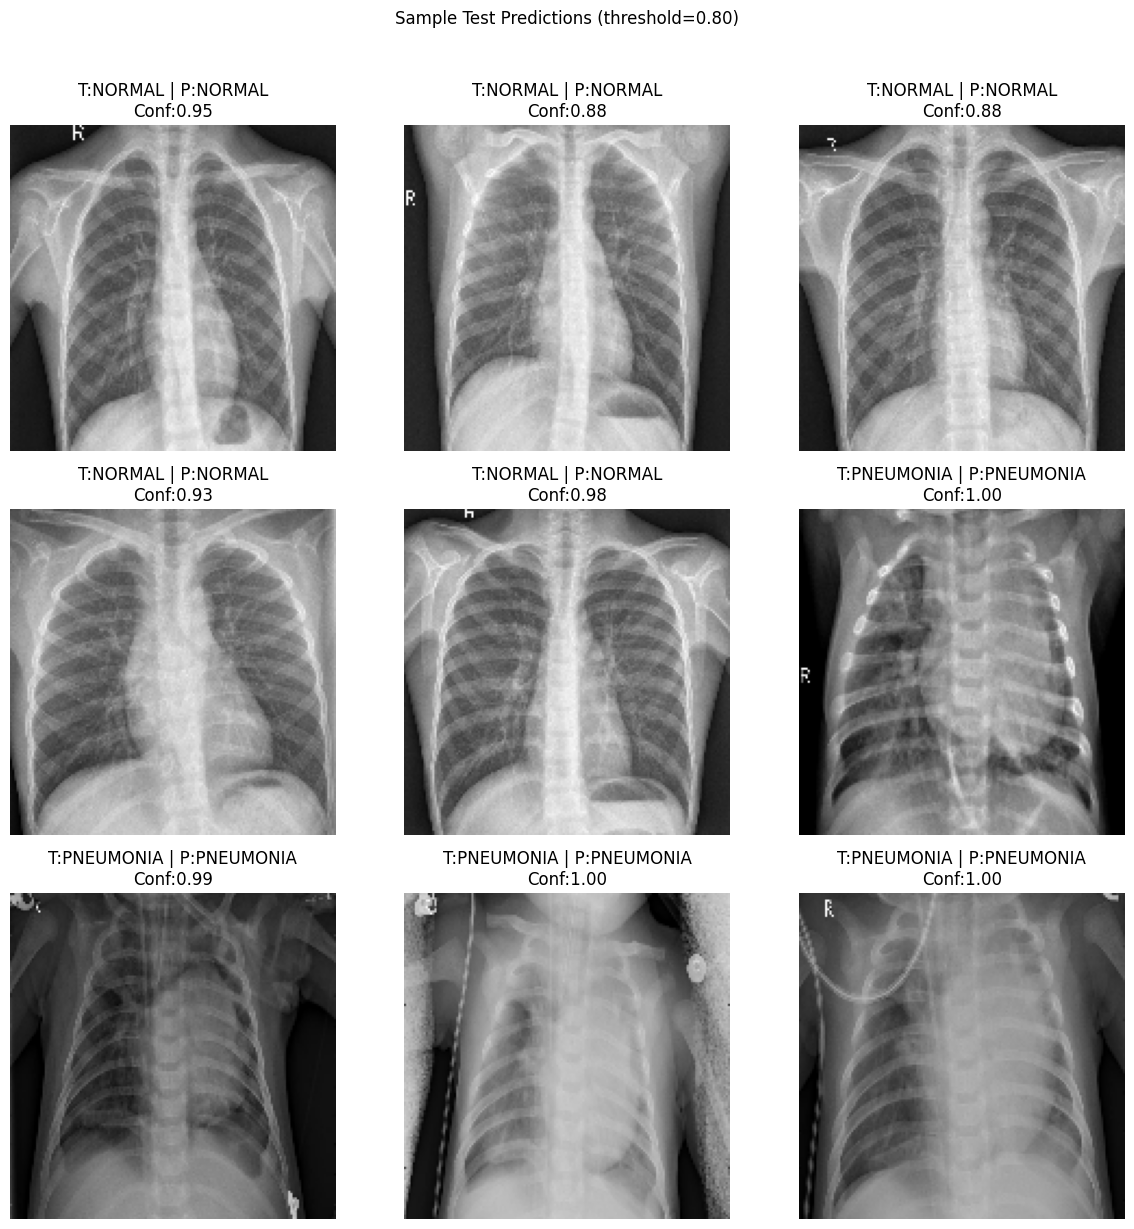

In [26]:
# Show sample predictions from test set (balanced sample: 5 NORMAL + 4 PNEUMONIA)
normal_images, pneumonia_images = [], []
normal_true, pneumonia_true = [], []

for images, labels in test_ds:
    lbls = labels.numpy().ravel().astype(int)
    for i, lbl in enumerate(lbls):
        if lbl == 0 and len(normal_images) < 5:
            normal_images.append(images[i])
            normal_true.append(lbl)
        elif lbl == 1 and len(pneumonia_images) < 4:
            pneumonia_images.append(images[i])
            pneumonia_true.append(lbl)

    if len(normal_images) >= 5 and len(pneumonia_images) >= 4:
        break

sample_images = tf.stack(normal_images + pneumonia_images)
sample_true = np.array(normal_true + pneumonia_true, dtype=int)

sample_probs = best_model.predict(sample_images, verbose=0).ravel()
sample_preds = (sample_probs >= best_threshold).astype(int)

idx_to_class = {0: "NORMAL", 1: "PNEUMONIA"}

plt.figure(figsize=(12, 12))
plt.suptitle(f"Sample Test Predictions (threshold={best_threshold:.2f})", y=1.02)
for i in range(len(sample_images)):
    img = sample_images[i].numpy().astype("uint8")
    true_label = idx_to_class[int(sample_true[i])]
    pred_label = idx_to_class[int(sample_preds[i])]
    conf = sample_probs[i] if sample_preds[i] == 1 else (1 - sample_probs[i])

    plt.subplot(3, 3, i + 1)
    plt.imshow(img.astype("uint8"))
    plt.title(f"T:{true_label} | P:{pred_label}\nConf:{conf:.2f}")
    plt.axis("off")

plt.tight_layout()
plt.show()

## 8) Overfitting Countermeasures Used

1. Medically safe data augmentation (`RandomFlip`, mild `RandomRotation`, mild `RandomZoom`, mild `RandomTranslation`, `RandomContrast`).
2. Batch normalization after each convolution block.
3. Progressive dropout in conv blocks plus classifier dropout.
4. L2 regularization in convolution and dense layers.
5. Gradient clipping (`clipnorm=1.0`) in Adam optimizer.
6. Conservative optimizer settings (`learning_rate=0.001`, `label_smoothing=0.02`) for smoother convergence.
7. Early stopping and LR scheduling on `val_accuracy`.

## 9) Baseline CNN Hyperparameter Tuning (Keras Tuner)

Search for better hyperparameters with Bayesian optimization, then train/evaluate the best tuned model.

In [27]:
def build_baseline_model_from_hp(hp):
    inputs = keras.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3))
    x = data_augmentation(inputs)
    x = layers.Rescaling(1.0 / 255)(x)

    num_blocks = hp.Choice("num_blocks", [3, 4])
    start_filters = hp.Choice("start_filters", [32, 64])
    kernel_size = hp.Choice("kernel_size", [3, 5])
    block_dropout = hp.Float("block_dropout", min_value=0.15, max_value=0.35, step=0.05)

    filters = start_filters
    for _ in range(num_blocks):
        x = layers.Conv2D(filters, (kernel_size, kernel_size), padding="same", activation="relu")(x)
        x = layers.BatchNormalization()(x)
        x = layers.Conv2D(filters, (kernel_size, kernel_size), padding="same", activation="relu")(x)
        x = layers.BatchNormalization()(x)
        x = layers.MaxPooling2D((2, 2))(x)
        x = layers.Dropout(block_dropout)(x)
        filters = min(filters * 2, 512)

    l2_value = hp.Choice("l2_reg", [1e-4, 1e-3, 1e-2])
    dense_units = hp.Choice("dense_units", [128, 256, 512])
    dense_dropout = hp.Float("dense_dropout", min_value=0.2, max_value=0.5, step=0.05)

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(dense_units, activation="relu", kernel_regularizer=keras.regularizers.l2(l2_value))(x)
    x = layers.Dropout(dense_dropout)(x)
    outputs = layers.Dense(1, activation="sigmoid")(x)

    tuning_model = keras.Model(inputs=inputs, outputs=outputs, name="baseline_cnn_tunable")
    learning_rate = hp.Choice("learning_rate", [0.001, 0.005, 0.0001, 0.0005])
    tuning_model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate, clipnorm=1.0),
        loss=keras.losses.BinaryCrossentropy(label_smoothing=0.02),
        metrics=[
            "accuracy",
            keras.metrics.AUC(name="auc"),
            keras.metrics.AUC(name="pr_auc", curve="PR")
        ],
    )
    return tuning_model

In [28]:
hp_callbacks = [
    keras.callbacks.EarlyStopping(monitor="val_accuracy", mode="max", patience=3, restore_best_weights=True),
]

tuned_callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        mode="max",
        patience=3,
        restore_best_weights=True,
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_accuracy",
        mode="max",
        factor=0.3,
        patience=3,
        min_lr=1e-7,
    ),
    keras.callbacks.ModelCheckpoint(
        TUNED_CHECKPOINT_PATH,
        monitor="val_accuracy",
        mode="max",
        save_best_only=True,
    ),
    keras.callbacks.TerminateOnNaN(),
]

tuner = kt.BayesianOptimization(
    build_baseline_model_from_hp,
    objective=kt.Objective("val_accuracy", direction="max"),
    max_trials=7,
    directory=str(SAVE_DIR),
    project_name="baseline_cnn_tuning",
    overwrite=False,
)

tuner.search(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    steps_per_epoch=steps_per_epoch,
    callbacks=hp_callbacks,
    verbose=1,
)
best_hp = tuner.get_best_hyperparameters(1)[0]
print("Best hyperparameters:", best_hp.values)

Trial 7 Complete [00h 38m 22s]
val_accuracy: 0.9293892979621887

Best val_accuracy So Far: 0.9770992398262024
Total elapsed time: 05h 55m 14s
Best hyperparameters: {'num_blocks': 3, 'start_filters': 32, 'kernel_size': 5, 'block_dropout': 0.25, 'l2_reg': 0.0001, 'dense_units': 128, 'dense_dropout': 0.25, 'learning_rate': 0.005}


In [29]:
# Train (or resume) tuned baseline model
if TUNED_CHECKPOINT_PATH.exists():
    print(f"Loading existing tuned checkpoint: {TUNED_CHECKPOINT_PATH}")
    baseline_tuned_model = load_model(TUNED_CHECKPOINT_PATH)
    baseline_tuned_history = None
else:
    baseline_tuned_model = build_baseline_model_from_hp(best_hp)
    baseline_tuned_history = baseline_tuned_model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=EPOCHS,
        steps_per_epoch=steps_per_epoch,
        callbacks=tuned_callbacks,
        verbose=1,
    )
    print(f"Best tuned checkpoint saved to: {TUNED_CHECKPOINT_PATH}")

Epoch 1/20
218/218 ━━━━━━━━━━━━━━━━━━━━ 331s 1s/step - accuracy: 0.8691 - auc: 0.9340 - loss: 0.3562 - pr_auc: 0.9431 - val_accuracy: 0.7920 - val_auc: 0.8313 - val_loss: 0.4591 - val_pr_auc: 0.9329 - learning_rate: 0.0050
Epoch 2/20
218/218 ━━━━━━━━━━━━━━━━━━━━ 327s 1s/step - accuracy: 0.9174 - auc: 0.9716 - loss: 0.2536 - pr_auc: 0.9727 - val_accuracy: 0.2805 - val_auc: 0.5645 - val_loss: 7.9627 - val_pr_auc: 0.8011 - learning_rate: 0.0050
Epoch 3/20
218/218 ━━━━━━━━━━━━━━━━━━━━ 325s 1s/step - accuracy: 0.9329 - auc: 0.9804 - loss: 0.2204 - pr_auc: 0.9809 - val_accuracy: 0.6145 - val_auc: 0.9703 - val_loss: 0.9690 - val_pr_auc: 0.9899 - learning_rate: 0.0050
Epoch 4/20
218/218 ━━━━━━━━━━━━━━━━━━━━ 327s 2s/step - accuracy: 0.9391 - auc: 0.9826 - loss: 0.2090 - pr_auc: 0.9832 - val_accuracy: 0.3931 - val_auc: 0.8558 - val_loss: 1.4785 - val_pr_auc: 0.9410 - learning_rate: 0.0050
Best tuned checkpoint saved to: saved_models\baseline_tuned_best_checkpoint.keras


In [32]:
# Threshold tuning (macro F1) and test evaluation for tuned model
val_true_batches, val_prob_batches = [], []
for images, labels in val_ds:
    probs = baseline_tuned_model.predict(images, verbose=0).ravel()
    val_prob_batches.append(probs)
    val_true_batches.append(labels.numpy().ravel())

val_true = np.concatenate(val_true_batches).astype(int)
val_prob = np.concatenate(val_prob_batches)
thresholds = np.linspace(0.05, 0.95, 91)
val_macro_f1_scores = []
for t in thresholds:
    val_pred_t = (val_prob >= t).astype(int)
    report_t = classification_report(
        val_true,
        val_pred_t,
        target_names=["NORMAL", "PNEUMONIA"],
        output_dict=True,
        zero_division=0,
    )
    macro_f1 = (report_t["NORMAL"]["f1-score"] + report_t["PNEUMONIA"]["f1-score"]) / 2
    val_macro_f1_scores.append(macro_f1)
baseline_tuned_threshold = float(thresholds[int(np.argmax(val_macro_f1_scores))])

y_true_batches, y_prob_batches = [], []
for images, labels in test_ds:
    probs = baseline_tuned_model.predict(images, verbose=0).ravel()
    y_prob_batches.append(probs)
    y_true_batches.append(labels.numpy().ravel())
y_true = np.concatenate(y_true_batches).astype(int)
y_prob = np.concatenate(y_prob_batches)
y_pred = (y_prob >= baseline_tuned_threshold).astype(int)

tuned_report = classification_report(
    y_true,
    y_pred,
    target_names=["NORMAL", "PNEUMONIA"],
    output_dict=True,
    zero_division=0,
)
baseline_tuned_metrics = {
    "accuracy": float((y_pred == y_true).mean()),
    "auc": float(roc_auc_score(y_true, y_prob)),
    "precision": float(tuned_report["PNEUMONIA"]["precision"]),
    "recall": float(tuned_report["PNEUMONIA"]["recall"]),
    "f1": float(tuned_report["PNEUMONIA"]["f1-score"]),
}

print(f"Tuned model threshold (macro F1): {baseline_tuned_threshold:.2f}")
print(f"Tuned model test ROC-AUC: {baseline_tuned_metrics['auc']:.4f}")

Tuned model threshold (macro F1): 0.68
Tuned model test ROC-AUC: 0.7150


In [33]:
# Save tuned model and metadata
save_model_with_meta(
    baseline_tuned_model,
    "baseline_cnn_tuned",
    baseline_tuned_metrics,
    baseline_tuned_history,
    best_hp.values,
    baseline_tuned_threshold,
)
print(f"Saved tuned baseline model with threshold {baseline_tuned_threshold:.2f}")

Saved model to: saved_models\baseline_cnn_tuned.keras
Saved metadata to: saved_models\baseline_cnn_tuned_meta.json
Saved tuned baseline model with threshold 0.68
